*February 11th, 2026*

<img src="https://imgur.com/tObZbvZ.png" height="200">

## **Long-read RNA-seq Analysis ─ Part 4**

*Uncovering transcriptomic features*

---

*Vinicius Maracaja-Coutinho* <sup>*,1,2,3</sup> and *Bárbara Borges* <sup>+,1,2</sup>

> <sup>*</sup> Principal Investigator ─ Bioinformatics PhD
>
> <sup>+</sup> Biotechnologist ─ Bioinformatics MSc(c)

<sup>1</sup> *Laboratory of Integrative Bioinformatics (LIB), Unidad de Genómica Avanzada, Universidad de Chile*

<sup>2</sup> *Bioinformatics Multidisciplinary Environment (BioME), UFRN, Brazil*

<sup>3</sup> *Laboratory of Precision Medicine and Health, Fiocruz Salvador, Brazil*


# **Environment setup**

### **Loading of R packages**

Download and set the R env file.

In [1]:
# download the R environment file, where you could change the environment file you build in the previous steps
R_environment_file <- "https://drive.usercontent.google.com/download?id=1s7NkfXo3mC1hZai-L0bBVDkQ4mQCD6Wa&export=download&authuser=0&confirm=t&uuid=0a876a76-72a5-41f4-8ccf-1bf98d14e5bc&at=APcXIO2D90ENCON4Y6W1OwcpiAE9:1770450565250"
download.file(R_environment_file,
      destfile="./library.tar.gz")

# unzip the compressed R library file: 'library.tar.gz' into the R library folder
untar("library.tar.gz", "library")

# change the R library directory into './library'
.libPaths("library")

**Required packages**

This cell loads plotting and Bioconductor packages used across the tutorial. During this step, the most important packages are `biomaRt`, the `tidyverse` collection, and `cowplot`.

In [ ]:
library(cowplot)
library(RColorBrewer)
library(viridis)
library(ggrepel)
library(pheatmap)
library(biomaRt)
library(ggbio)
library(apeglm)
library(httr)
library(tidyverse)
library(scales)
library(ggplot2)

## **Dataset**

### Non-small cell lung cancer

During Part 3, we identified differentially expressed reference genes and full-length isoforms from the HCC827 and NCI-H1975 lung adenocarcinoma cell lines (BioProject PRJNA723287). Now, we are going to retrieve the metadata generated in order to characterize transcriptomic features.

**Data sources and format**

Fetch the significantly isoform-level DE `.csv` metadata file.

In [3]:
# Download the DTE matrix and the original matrix to gather ensembl IDs

download.file("https://raw.githubusercontent.com/integrativebioinformatics/EBI-lrRNAseq-2026/refs/heads/main/data/dge_dte/reslfc_df_sig_dte.csv", destfile = "reslfc_df_sig_dte.csv")

download.file("https://raw.githubusercontent.com/integrativebioinformatics/EBI-lrRNAseq-2026/refs/heads/main/data/matrices/ref_tx_full_length_counts.tsv", destfile = "ref_tx_full_length_counts.tsv")

# **Introduction**

This part of the scripts analyze and visualize the annotated transcriptome assembled and quantified by Bambu. We will explore the distribution of various gene and transcript biotypes, investigate transcript lengths, and compare exon characteristics between protein-coding and lncRNA genes.

## 1. **Biotype Distribution Analysis**
We’ll begin by loading the transcriptome metadata and summarizing the counts of different transcript biotypes.

#### Data Loading and Preparation
The file `reslfc_df_sig_dte.csv`is loaded, and we count the occurrences of each transcript biotype, grouped by their corresponding gene biotype.

In [4]:
de <- read.csv("reslfc_df_sig_dte.csv")
de <- de %>%
  select(symbol, exp)

head(de)

,symbol,exp
,<chr>,<chr>
1,CRIP1-201,Downregulated
2,LCN2-201,Upregulated
3,PDZK1IP1-201,Upregulated
4,MT1E-201,Downregulated
5,IFITM2-205,Downregulated
6,DEFB4A-201,Upregulated


In [ ]:
ct <- read_table("ref_tx_full_length_counts.tsv")
ids <- ct$TXNAME

Connect to biomaRt

In [6]:
ensembl <- useEnsembl(biomart="genes", dataset="hsapiens_gene_ensembl", version=115)

In [7]:
attributes <- c("chromosome_name","ensembl_gene_id", "ensembl_transcript_id",
                "external_transcript_name","external_gene_name",
                "transcript_length", "gene_biotype", "transcript_biotype")

filters <- "ensembl_transcript_id"

ens_tx <- getBM(attributes=attributes, filters=filters, values=ids, mart=ensembl)

In [8]:
head(ens_tx)

,chromosome_name,ensembl_gene_id,ensembl_transcript_id,external_transcript_name,external_gene_name,transcript_length,gene_biotype,transcript_biotype
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,Y,ENSG00000154620,ENST00000284856,TMSB4Y-201,TMSB4Y,1337,protein_coding,protein_coding
2,21,ENSG00000229336,ENST00000282964,SREK1IP1P1-201,SREK1IP1P1,442,processed_pseudogene,processed_pseudogene
3,21,ENSG00000156282,ENST00000286808,CLDN17-201,CLDN17,1241,protein_coding,protein_coding
4,21,ENSG00000159228,ENST00000290349,CBR1-201,CBR1,1208,protein_coding,protein_coding
5,21,ENSG00000160216,ENST00000291572,AGPAT3-201,AGPAT3,6565,protein_coding,protein_coding
6,21,ENSG00000160182,ENST00000291527,TFF1-201,TFF1,492,protein_coding,protein_coding


Subset the informations to keep only the DE isoforms.

In [9]:
ens_tx <- ens_tx %>%
  mutate(external_transcript_name = ifelse(external_transcript_name == "" | is.na(external_transcript_name),
                                           ensembl_transcript_id, external_transcript_name)) %>%
  mutate(external_gene_name = ifelse(external_gene_name == "" | is.na(external_gene_name),
                                    ensembl_gene_id, external_gene_name)) %>%
                                    distinct(external_transcript_name, .keep_all = TRUE)

ens <- merge(de, ens_tx, by.x="symbol", by.y="external_transcript_name", all.x=TRUE)

head(ens)

,symbol,exp,chromosome_name,ensembl_gene_id,ensembl_transcript_id,external_gene_name,transcript_length,gene_biotype,transcript_biotype
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,7SK.1-201,Upregulated,6,ENSG00000202198,ENST00000365328,7SK,331,misc_RNA,misc_RNA
2,A1BG-AS1-209,Downregulated,19,ENSG00000268895,ENST00000670460,A1BG-AS1,1869,lncRNA,lncRNA
3,AAAS-201,Upregulated,12,ENSG00000094914,ENST00000209873,AAAS,1815,protein_coding,protein_coding
4,AADAT-201,Downregulated,4,ENSG00000109576,ENST00000337664,AADAT,2250,protein_coding,protein_coding
5,AAGAB-201,Downregulated,15,ENSG00000103591,ENST00000261880,AAGAB,3132,protein_coding,protein_coding
6,AAMDC-202,Upregulated,11,ENSG00000087884,ENST00000393427,AAMDC,522,protein_coding,protein_coding


**Group transcripts by biotype**

In [10]:
# Count each transcript biotype based on gene biotype
summary_data <- ens %>%
  group_by(gene_biotype, transcript_biotype) %>%
  summarise(count = n_distinct(ensembl_transcript_id), .groups = 'drop')

summary_data

gene_biotype,transcript_biotype,count
<chr>,<chr>,<int>
Mt_rRNA,Mt_rRNA,2
TEC,TEC,8
TR_V_gene,TR_V_gene,1
artifact,artifact,6
lncRNA,lncRNA,2085
lncRNA,retained_intron,13
misc_RNA,misc_RNA,1
processed_pseudogene,processed_pseudogene,65
protein_coding,non_stop_decay,1


To make plotting more manageable, we categorize the gene biotypes into logical groups of protein-coding and long non-coding RNAs.

**Plotting Function**

A reusable function is created to generate consistent bar plots for different data subsets. This function standardizes aesthetics, titles, and scales.



In [11]:
create_plot <- function(data, x, fill, title) {
  ggplot(data, aes(x = {{x}}, y = count, fill = {{fill}})) +
    geom_bar(stat = "identity", position = "dodge2") +
    labs(x = "\nGene biotypes", y = "Count (log10 scale)\n", fill = "Transcript biotypes",
         title = title) +
    theme(axis.text.x = element_text(size=12, hjust = 0.5),
          legend.position = "right",
          legend.title = element_text(size = 12, face = "bold"),
          legend.text = element_text(size=12),
          plot.title = element_text(size=13, hjust = 0.5, face = "bold"),
          axis.title.y = element_text(size=12, face = "bold"),
          axis.title.x = element_text(size= 12, face = "bold"),
          plot.margin = margin(1, 1, 1, 1, "cm")
    ) +
    scale_y_log10(
      breaks = trans_breaks("log10", function(x) 10^x),
      labels = comma
    ) +
    geom_text(
      aes(label = count),
      position = position_dodge2(width = 0.9),
      vjust = -0.5,
      hjust = 0.5,
      size = 4
    )
}

Here we generate and display the plots for each major RNA category.

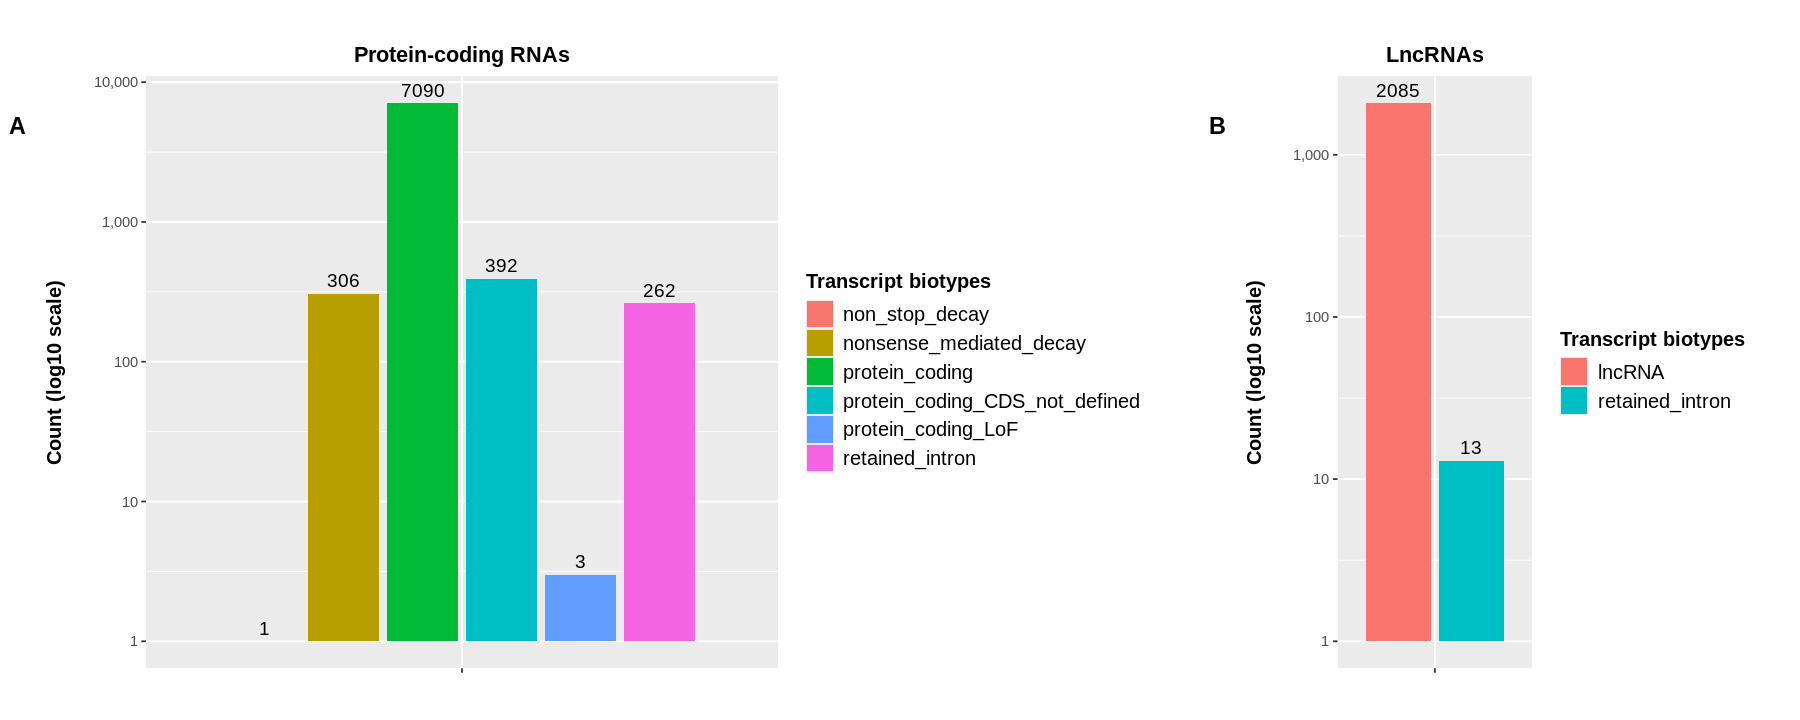

In [15]:
options(repr.plot.width = 15, repr.plot.height = 6)

# Filter for protein_coding and lncRNA biotypes
protein_coding <- summary_data %>% filter(gene_biotype == "protein_coding")
lncRNAs <- summary_data %>% filter(gene_biotype == "lncRNA")

p1 <- create_plot(protein_coding, gene_biotype, transcript_biotype, "Protein-coding RNAs") + theme(axis.text.x = element_blank(),
                                                 axis.title.x = element_blank())

p2 <- create_plot(lncRNAs, gene_biotype, transcript_biotype, "LncRNAs") +
      theme(axis.text.x = element_blank(), axis.title.x = element_blank())

p3 <- plot_grid(p1, p2, ncol = 2, rel_widths = c(2,1),
                   labels = "AUTO", label_size = 14, label_y = 0.85)

p3

**What are the specific biotypes of the DE isoforms?**

In [20]:
lnc_pc_summary <- ens %>%
  filter(gene_biotype %in% c("protein_coding", "lncRNA")) %>%
  group_by(gene_biotype, transcript_biotype, exp) %>%
  summarise(count = n_distinct(ensembl_transcript_id), .groups = 'drop')

lnc_pc_summary

gene_biotype,transcript_biotype,exp,count
<chr>,<chr>,<chr>,<int>
lncRNA,lncRNA,Downregulated,1367
lncRNA,lncRNA,Upregulated,718
lncRNA,retained_intron,Downregulated,6
lncRNA,retained_intron,Upregulated,7
protein_coding,non_stop_decay,Downregulated,1
protein_coding,nonsense_mediated_decay,Downregulated,196
protein_coding,nonsense_mediated_decay,Upregulated,110
protein_coding,protein_coding,Downregulated,3356
protein_coding,protein_coding,Upregulated,3734


**Gene Biotype diversity across chromosomes**

Here we generate and display the plots for each gene biotype across all assembled chromosomes.

Group, count, and prepare the chromosome data. Organize names, sort numbers and names and convert to factors to order them.

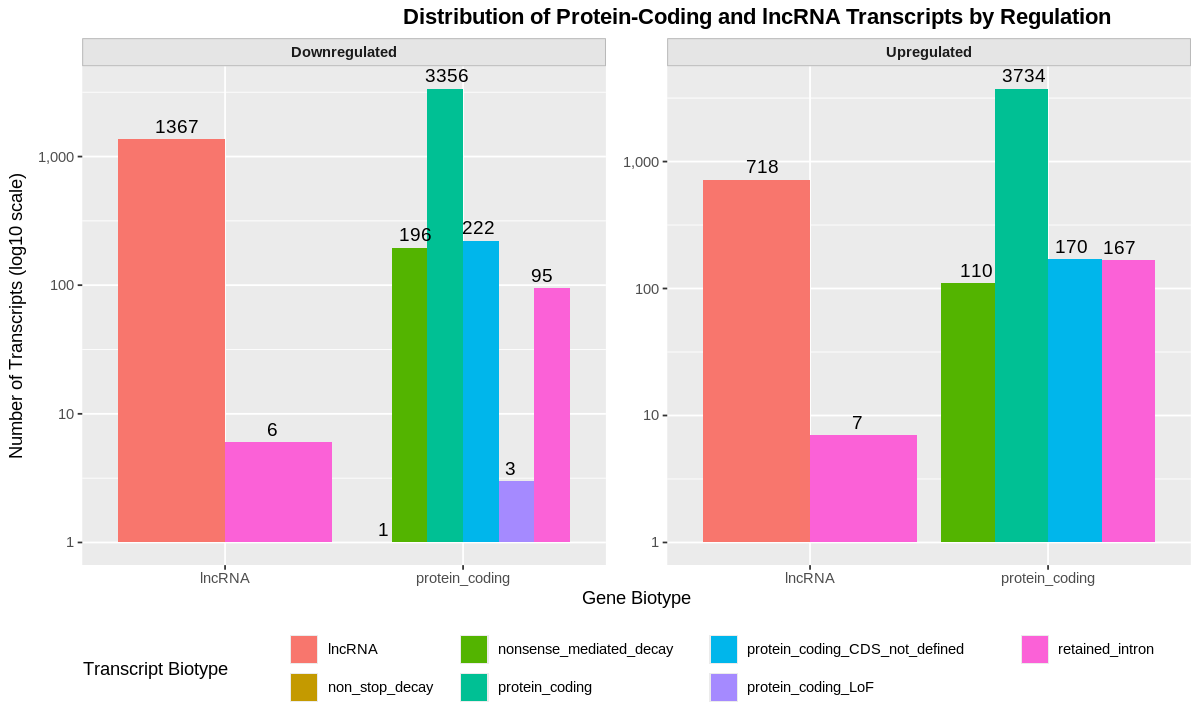

In [24]:
options(repr.plot.width = 10, repr.plot.height = 6)


p6 <- ggplot(lnc_pc_summary, aes(x = gene_biotype, y = count, fill = transcript_biotype)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~exp, scales = "free_y") + # Facet by regulation
  labs(
    title = "Distribution of Protein-Coding and lncRNA Transcripts by Regulation",
    x = "Gene Biotype",
    y = "Number of Transcripts (log10 scale)",
    fill = "Transcript Biotype"
  ) +
  scale_y_log10(labels = scales::comma_format()) + # Log scale for y-axis
  theme(
    legend.position = "bottom",
    plot.title = element_text(hjust = 0.8, face = "bold"),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    strip.background = element_rect(fill = "grey90", color = "grey70"),
    strip.text = element_text(face = "bold")
  ) +
     geom_text(
      aes(label = count),
      position = position_dodge2(width = 0.8),
      vjust = -0.5,
      hjust = 0.5,
      size = 4
    )

p6

In [16]:
chr_gb <- ens %>%
  mutate(
    gene_biotype = if_else(
      str_detect(gene_biotype, "pseudogene"),
      "pseudogene",
      gene_biotype
    )
  ) %>%
  group_by(chromosome_name, gene_biotype) %>%
  summarise(count = n(), .groups = 'drop')

# Extract chromosome names
chromosome_names <- unique(chr_gb$chromosome_name)

# Separate numeric and non-numeric chromosomes
numeric_chromosomes <- grep("^[0-9]+$", chromosome_names, value = TRUE)
non_numeric_chromosomes <- setdiff(chromosome_names,
                                   numeric_chromosomes)

# Sort numeric chromosomes numerically
numeric_chromosomes_sorted <- as.character(sort(as.numeric(numeric_chromosomes)))

# Combine sorted numeric and non-numeric chromosomes
chromosome_order <- c(numeric_chromosomes_sorted, sort(non_numeric_chromosomes))

# Convert chromosome_name to a factor with the desired order
chr_gb$chromosome_name <- factor(chr_gb$chromosome_name, levels = chromosome_order)

head(chr_gb)

chromosome_name,gene_biotype,count
<fct>,<chr>,<int>
1,TEC,1
1,lncRNA,198
1,protein_coding,826
1,pseudogene,13
10,lncRNA,87
10,protein_coding,261


In [17]:
options(repr.plot.width = 45, repr.plot.height = 40)

p4 <- ggplot(chr_gb, aes(x = gene_biotype, y = count)) +

  ggplot2::geom_bar(stat = "identity",
           aes(fill = gene_biotype),
           alpha = 1,
           width = 0.8) +

  facet_wrap(~ chromosome_name, scales = "free_x", ncol = 5) +
  scale_fill_viridis_d(option = "viridis", guide = "none") +
  scale_y_log10(labels = scales::comma_format()) +
  theme_minimal() +
  theme(
    panel.background = element_rect(fill = "white", color = "grey90"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5,
                               size = 20, margin = margin(t = 5, b = 10)),
    axis.text.y = element_text(size = 20),
    axis.title.x = element_text(size = 20, face = "bold"),
    axis.title.y = element_text(size = 20, face = "bold"),
    strip.text = element_text(size = 20, face = "bold", color = "black",
                              margin = margin(t = 8, b = 8, l = 5, r = 5)),
    strip.background = element_rect(fill = "grey85", color = "grey70",
                                    linewidth = 0.5),
    text = element_text(size = 14),
    plot.title = element_text(size = 32, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 24, hjust = 0.5),
    plot.margin = margin(1, 1, 1, 1, "cm"),
    panel.spacing = unit(1.2, "cm")
  ) +
  labs(
    title = "Gene Biotype Diversity Across Human Chromosomes",
    subtitle = "Distribution of different gene types per chromosome (log10 scale)",
    x = "Gene Biotype",
    y = "Count (log10 scale)" )+
    ggplot2::geom_text(aes(label = count),
            vjust = -0.5,
            size = 5,
            color = "black")

ggplot2::ggsave("chr_gb.pdf", p4, dpi = 300, width=30, height=40)

## 2. **Transcript Length Analysis**

Next, we analyze the transcript lengths across different gene biotypes.

**Length Distribution by Gene and Transcript Biotype**

We filter for specific biotypes of interest and create boxplots to compare their transcript length distributions.

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 6)

selected_tx <- ens %>%
  filter(gene_biotype %in% c("protein_coding", "lncRNA"))

selected_tx$gene_biotype <- factor(selected_tx$gene_biotype,
                                   levels = c("protein_coding", "lncRNA"))

median_stx <- selected_tx %>%
  group_by(gene_biotype) %>%
  summarise(median_length = median(transcript_length), .groups = 'drop')

p5 <- ggplot(selected_tx, aes(x = gene_biotype, y = transcript_length, fill = factor(gene_biotype))) +
  geom_boxplot() +
  labs(title = "Transcript length across gene biotypes",
       x = "Gene biotype",
       y = "Transcript length (log10 scale)",
       fill = "Gene biotype\n(median length)") +
  scale_y_log10() +
  scale_fill_discrete(labels = paste0(median_stx$gene_biotype, " (", round(median_stx$median_length, 2), ")"))

p5

We now look deeper into the protein_coding and lncRNA categories to see how transcript length varies by their respective transcript biotypes.

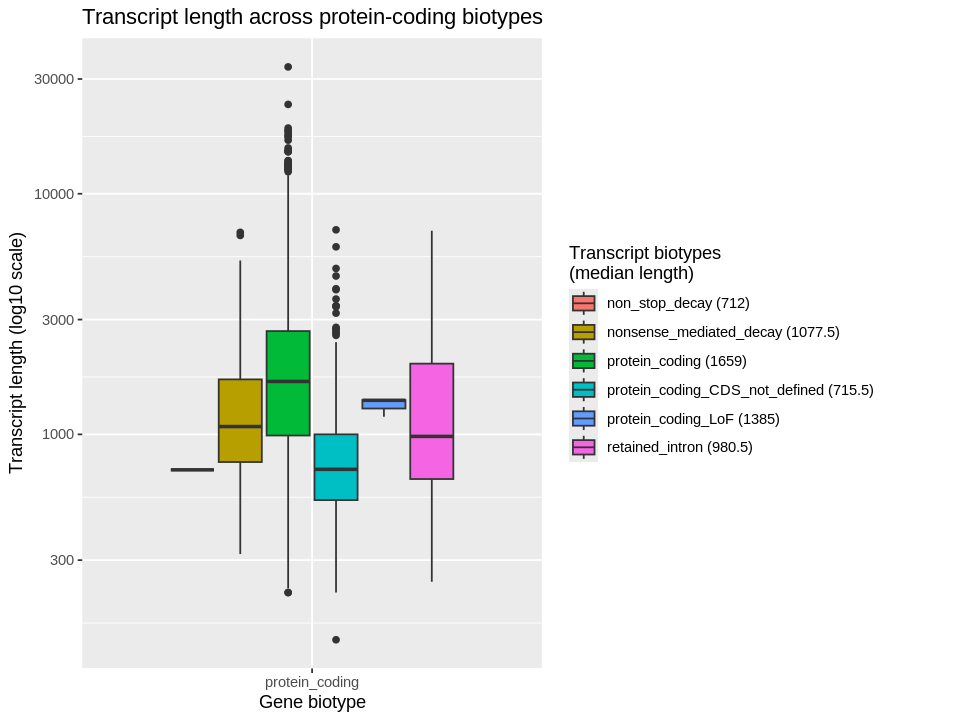

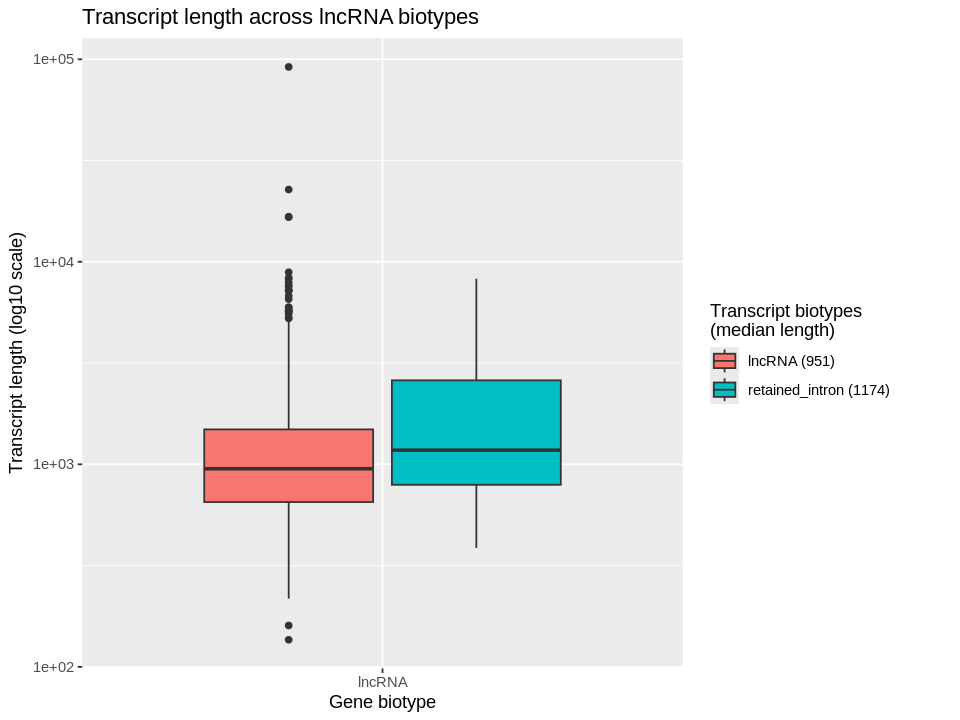

In [26]:
# Protein-coding plot
median_pc <- selected_tx %>%
  filter(gene_biotype == "protein_coding") %>%
  group_by(transcript_biotype) %>%
  summarise(median_length_txb = median(transcript_length), .groups = 'drop')

p11 <- selected_tx %>%
  filter(gene_biotype == "protein_coding") %>%
  ggplot(aes(x = gene_biotype, y = transcript_length, fill = transcript_biotype)) +
  geom_boxplot() +
  labs(title = "Transcript length across protein-coding biotypes",
       x = "Gene biotype", y = "Transcript length (log10 scale)",
       fill = "Transcript biotypes\n(median length)") +
  scale_y_log10() +
  scale_fill_discrete(labels = paste0(median_pc$transcript_biotype, " (", round(median_pc$median_length_txb, 2), ")"))

p11

# lncRNA plot
median_lnc <- selected_tx %>%
  filter(gene_biotype == "lncRNA") %>%
  group_by(transcript_biotype) %>%
  summarise(median_length_txb = median(transcript_length), .groups = 'drop')

p12 <- selected_tx %>%
  filter(gene_biotype == "lncRNA") %>%
  ggplot(aes(x = gene_biotype, y = transcript_length, fill = transcript_biotype)) +
  geom_boxplot() +
  labs(title = "Transcript length across lncRNA biotypes",
       x = "Gene biotype", y = "Transcript length (log10 scale)",
       fill = "Transcript biotypes\n(median length)") +
  scale_y_log10() +
  scale_fill_discrete(labels = paste0(median_lnc$transcript_biotype, " (", round(median_lnc$median_length_txb, 2), ")"))

p12